In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/bharanikumar55/bbc-hindi-dataset/bbc_train.parquet
/kaggle/input/datasets/bharanikumar55/bbc-hindi-dataset/bbc_test.parquet


In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/bharanikumar55/bbc-hindi-dataset/bbc_train.parquet
/kaggle/input/datasets/bharanikumar55/bbc-hindi-dataset/bbc_test.parquet


## Loading The Dataset

In [3]:
import pandas as pd

train = pd.read_parquet("/kaggle/input/datasets/bharanikumar55/bbc-hindi-dataset/bbc_train.parquet")
test = pd.read_parquet("/kaggle/input/datasets/bharanikumar55/bbc-hindi-dataset/bbc_test.parquet")

In [4]:
train.head()

,label,text
0,india,मेट्रो की इस लाइन के चलने से दक्षिणी दिल्ली से...
1,pakistan,नेटिजन यानि इंटरनेट पर सक्रिय नागरिक अब ट्विटर...
2,news,इसमें एक फ़्लाइट एटेनडेंट की मदद की गुहार है औ...
3,india,"प्रतीक खुलेपन का, आज़ाद ख्याली का और भीड़ से अ..."
4,india,ख़ासकर पिछले 10 साल तक प्रधानमंत्री रहे मनमोहन...


## TEXT PREPROCESSING

### 1.Removing Numbers
### 2.Keeping only Hindi Characters
### 3. Removing Extra Spaces


In [5]:
import re

def clean_text(text):
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Keep only Hindi characters
    text = re.sub(r'[^\u0900-\u097F\s]', '', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [6]:
train['clean_text'] = train['text'].apply(clean_text)
test['clean_text'] = test['text'].apply(clean_text)

In [7]:
train.head()

,label,text,clean_text
0,india,मेट्रो की इस लाइन के चलने से दक्षिणी दिल्ली से...,मेट्रो की इस लाइन के चलने से दक्षिणी दिल्ली से...
1,pakistan,नेटिजन यानि इंटरनेट पर सक्रिय नागरिक अब ट्विटर...,नेटिजन यानि इंटरनेट पर सक्रिय नागरिक अब ट्विटर...
2,news,इसमें एक फ़्लाइट एटेनडेंट की मदद की गुहार है औ...,इसमें एक फ़्लाइट एटेनडेंट की मदद की गुहार है औ...
3,india,"प्रतीक खुलेपन का, आज़ाद ख्याली का और भीड़ से अ...",प्रतीक खुलेपन का आज़ाद ख्याली का और भीड़ से अल...
4,india,ख़ासकर पिछले 10 साल तक प्रधानमंत्री रहे मनमोहन...,ख़ासकर पिछले साल तक प्रधानमंत्री रहे मनमोहन सि...


### Tokenization

In [8]:
train['tokens'] = train['clean_text'].apply(lambda x: x.split())
test['tokens'] = test['clean_text'].apply(lambda x: x.split())

In [9]:
train.head()


,label,text,clean_text,tokens
0,india,मेट्रो की इस लाइन के चलने से दक्षिणी दिल्ली से...,मेट्रो की इस लाइन के चलने से दक्षिणी दिल्ली से...,"[मेट्रो, की, इस, लाइन, के, चलने, से, दक्षिणी, ..."
1,pakistan,नेटिजन यानि इंटरनेट पर सक्रिय नागरिक अब ट्विटर...,नेटिजन यानि इंटरनेट पर सक्रिय नागरिक अब ट्विटर...,"[नेटिजन, यानि, इंटरनेट, पर, सक्रिय, नागरिक, अब..."
2,news,इसमें एक फ़्लाइट एटेनडेंट की मदद की गुहार है औ...,इसमें एक फ़्लाइट एटेनडेंट की मदद की गुहार है औ...,"[इसमें, एक, फ़्लाइट, एटेनडेंट, की, मदद, की, गु..."
3,india,"प्रतीक खुलेपन का, आज़ाद ख्याली का और भीड़ से अ...",प्रतीक खुलेपन का आज़ाद ख्याली का और भीड़ से अल...,"[प्रतीक, खुलेपन, का, आज़ाद, ख्याली, का, और, भी..."
4,india,ख़ासकर पिछले 10 साल तक प्रधानमंत्री रहे मनमोहन...,ख़ासकर पिछले साल तक प्रधानमंत्री रहे मनमोहन सि...,"[ख़ासकर, पिछले, साल, तक, प्रधानमंत्री, रहे, मन..."


### Stopword Removal

In [10]:
stopwords = ['है', 'और', 'में', 'को', 'का', 'की']

In [11]:
def remove_stopwords(tokens):
    return [word for word in tokens if word not in stopwords]

train['tokens_stopword_removal'] = train['tokens'].apply(remove_stopwords)
test['tokens_stopword_removal'] = test['tokens'].apply(remove_stopwords)

In [12]:
train.head()

,label,text,clean_text,tokens,tokens_stopword_removal
0,india,मेट्रो की इस लाइन के चलने से दक्षिणी दिल्ली से...,मेट्रो की इस लाइन के चलने से दक्षिणी दिल्ली से...,"[मेट्रो, की, इस, लाइन, के, चलने, से, दक्षिणी, ...","[मेट्रो, इस, लाइन, के, चलने, से, दक्षिणी, दिल्..."
1,pakistan,नेटिजन यानि इंटरनेट पर सक्रिय नागरिक अब ट्विटर...,नेटिजन यानि इंटरनेट पर सक्रिय नागरिक अब ट्विटर...,"[नेटिजन, यानि, इंटरनेट, पर, सक्रिय, नागरिक, अब...","[नेटिजन, यानि, इंटरनेट, पर, सक्रिय, नागरिक, अब..."
2,news,इसमें एक फ़्लाइट एटेनडेंट की मदद की गुहार है औ...,इसमें एक फ़्लाइट एटेनडेंट की मदद की गुहार है औ...,"[इसमें, एक, फ़्लाइट, एटेनडेंट, की, मदद, की, गु...","[इसमें, एक, फ़्लाइट, एटेनडेंट, मदद, गुहार, साथ..."
3,india,"प्रतीक खुलेपन का, आज़ाद ख्याली का और भीड़ से अ...",प्रतीक खुलेपन का आज़ाद ख्याली का और भीड़ से अल...,"[प्रतीक, खुलेपन, का, आज़ाद, ख्याली, का, और, भी...","[प्रतीक, खुलेपन, आज़ाद, ख्याली, भीड़, से, अलग,..."
4,india,ख़ासकर पिछले 10 साल तक प्रधानमंत्री रहे मनमोहन...,ख़ासकर पिछले साल तक प्रधानमंत्री रहे मनमोहन सि...,"[ख़ासकर, पिछले, साल, तक, प्रधानमंत्री, रहे, मन...","[ख़ासकर, पिछले, साल, तक, प्रधानमंत्री, रहे, मन..."


## FastText for Converting to vectors

In [13]:
!pip install gensim

In [14]:
from gensim.models import FastText
import numpy as np

In [15]:
sentences = train['tokens_stopword_removal'].tolist()

In [16]:
fasttext_model = FastText(
    sentences,
    vector_size=100,   # size of word vectors
    window=5,          # context size
    min_count=1,       # include all words
    workers=4
)

In [17]:
fasttext_model_inc = FastText(
    sentences,
    vector_size=100,   # size of word vectors
    window=5,          # context size
    min_count=1,       # include all words
    workers=4
)

In [18]:
def get_sentence_vector(tokens, model):
    vectors = []
    
    for word in tokens:
        if word in model.wv:
            vectors.append(model.wv[word])
    
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    
    return np.mean(vectors, axis=0)

#### After removing stopwords

In [19]:
train['fasttext_vector'] = train['tokens_stopword_removal'].apply(
    lambda x: get_sentence_vector(x, fasttext_model_inc)
)

test['fasttext_vector'] = test['tokens_stopword_removal'].apply(
    lambda x: get_sentence_vector(x, fasttext_model_inc)
)

#### Not removing stopwords

In [20]:
train['fasttext_vector_no_stop_inc'] = train['tokens'].apply(
    lambda x: get_sentence_vector(x, fasttext_model_inc)
)

test['fasttext_vector_no_stop_inc'] = test['tokens'].apply(
    lambda x: get_sentence_vector(x, fasttext_model_inc)
)

In [21]:
train.head()

,label,text,clean_text,tokens,tokens_stopword_removal,fasttext_vector,fasttext_vector_no_stop_inc
0,india,मेट्रो की इस लाइन के चलने से दक्षिणी दिल्ली से...,मेट्रो की इस लाइन के चलने से दक्षिणी दिल्ली से...,"[मेट्रो, की, इस, लाइन, के, चलने, से, दक्षिणी, ...","[मेट्रो, इस, लाइन, के, चलने, से, दक्षिणी, दिल्...","[0.03667791, -0.30313876, -0.080183, -0.569779...","[0.025823928, -0.4826367, -0.12945709, -0.6574..."
1,pakistan,नेटिजन यानि इंटरनेट पर सक्रिय नागरिक अब ट्विटर...,नेटिजन यानि इंटरनेट पर सक्रिय नागरिक अब ट्विटर...,"[नेटिजन, यानि, इंटरनेट, पर, सक्रिय, नागरिक, अब...","[नेटिजन, यानि, इंटरनेट, पर, सक्रिय, नागरिक, अब...","[-0.43464994, -0.27077168, -0.17755046, -0.325...","[-0.3185393, -0.39811715, -0.16850816, -0.4972..."
2,news,इसमें एक फ़्लाइट एटेनडेंट की मदद की गुहार है औ...,इसमें एक फ़्लाइट एटेनडेंट की मदद की गुहार है औ...,"[इसमें, एक, फ़्लाइट, एटेनडेंट, की, मदद, की, गु...","[इसमें, एक, फ़्लाइट, एटेनडेंट, मदद, गुहार, साथ...","[-0.1467803, -0.33285978, -0.19757907, -0.4039...","[-0.12106906, -0.52611744, -0.19762087, -0.599..."
3,india,"प्रतीक खुलेपन का, आज़ाद ख्याली का और भीड़ से अ...",प्रतीक खुलेपन का आज़ाद ख्याली का और भीड़ से अल...,"[प्रतीक, खुलेपन, का, आज़ाद, ख्याली, का, और, भी...","[प्रतीक, खुलेपन, आज़ाद, ख्याली, भीड़, से, अलग,...","[-0.14088303, -0.333032, -0.38598862, -0.62989...","[-0.11714136, -0.52011585, -0.4086037, -0.7047..."
4,india,ख़ासकर पिछले 10 साल तक प्रधानमंत्री रहे मनमोहन...,ख़ासकर पिछले साल तक प्रधानमंत्री रहे मनमोहन सि...,"[ख़ासकर, पिछले, साल, तक, प्रधानमंत्री, रहे, मन...","[ख़ासकर, पिछले, साल, तक, प्रधानमंत्री, रहे, मन...","[-0.23845918, 0.09173542, -0.2725537, -0.58290...","[-0.1348189, -0.024525557, -0.27793953, -0.678..."


#### after removing stopwords


In [22]:
X_train = np.vstack(train['fasttext_vector'].values)
X_test = np.vstack(test['fasttext_vector'].values)


#### Not removing stop words

In [23]:
X_train_n = np.vstack(train['fasttext_vector_no_stop_inc'].values)
X_test_n = np.vstack(test['fasttext_vector_no_stop_inc'].values)


In [24]:
X_train_inc = np.vstack(train['fasttext_vector_no_stop_inc'].values)
X_test_inc = np.vstack(test['fasttext_vector_no_stop_inc'].values)


## AutoEncoder + FastText

In [25]:
import torch
import torch.nn as nn
import torch.optim as optim

In [26]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

In [27]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        # Encoder (compress)
        self.encoder = nn.Sequential(
            nn.Linear(100, 64),
            nn.ReLU(),
            nn.Linear(64, 32)   # LATENT SPACE
        )
        # Decoder (reconstruct)
        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 100)
        )
    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed

In [28]:
model = Autoencoder()

In [29]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [30]:
epochs = 20
for epoch in range(epochs):
    optimizer.zero_grad()
    output = model(X_train_tensor)
    loss = criterion(output, X_train_tensor)
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item()}")

Epoch 1, Loss: 0.28706875443458557
Epoch 2, Loss: 0.2793610692024231
Epoch 3, Loss: 0.2717088460922241
Epoch 4, Loss: 0.26398125290870667
Epoch 5, Loss: 0.255624383687973
Epoch 6, Loss: 0.24633575975894928
Epoch 7, Loss: 0.23607194423675537
Epoch 8, Loss: 0.2249331921339035
Epoch 9, Loss: 0.21274735033512115
Epoch 10, Loss: 0.19950543344020844
Epoch 11, Loss: 0.18538998067378998
Epoch 12, Loss: 0.17071586847305298
Epoch 13, Loss: 0.15596868097782135
Epoch 14, Loss: 0.14181753993034363
Epoch 15, Loss: 0.12904666364192963
Epoch 16, Loss: 0.11833589524030685
Epoch 17, Loss: 0.10988406091928482
Epoch 18, Loss: 0.1031075268983841
Epoch 19, Loss: 0.09691770374774933
Epoch 20, Loss: 0.0904199406504631


##### Reduced Loss from 0.024 to 0.020

In [31]:
with torch.no_grad():
    latent_train = model.encoder(X_train_tensor)
    latent_test = model.encoder(X_test_tensor)

In [32]:
latent_train.shape

torch.Size([3467, 32])

In [33]:
latent_train_np = latent_train.numpy()
latent_test_np = latent_test.numpy()

### Using LabelEncoder on Target(label) Values

In [34]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(train['label'])
y_test = le.transform(test['label'])

In [35]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = dict(enumerate(class_weights))

## Autoencoder plus classification with stopword removal

In [36]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000, class_weight='balanced')
clf.fit(latent_train_np, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [37]:
y_pred = clf.predict(latent_test_np)

In [38]:
from sklearn.metrics import accuracy_score, classification_report
fasttext_ae_acc=accuracy_score(y_test, y_pred)
print("Accuracy:",fasttext_ae_acc)
print(classification_report(y_test, y_pred))

Accuracy: 0.3083140877598152
              precision    recall  f1-score   support

           0       0.04      0.29      0.06         7
           1       0.00      0.00      0.00         5
           2       0.41      0.61      0.49        71
           3       0.86      0.20      0.33       357
           4       0.07      0.50      0.12         4
           5       0.64      0.23      0.33       212
           6       0.00      0.00      0.00         3
           7       0.04      1.00      0.08         1
           8       0.18      0.08      0.11        49
           9       0.03      0.38      0.06         8
          10       0.28      0.57      0.38        61
          11       0.05      0.67      0.10         6
          12       0.10      0.40      0.15        10
          13       0.71      0.68      0.70        72

    accuracy                           0.31       866
   macro avg       0.24      0.40      0.21       866
weighted avg       0.64      0.31      0.35       8

## Logistic Regression: Stopword removal include and classification

In [39]:
from sklearn.linear_model import LogisticRegression

clf_n = LogisticRegression(max_iter=1000, class_weight='balanced')
clf_n.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [40]:
y_pred_n = clf_n.predict(X_test)

In [41]:
from sklearn.metrics import accuracy_score, classification_report
fasttext_logacc=accuracy_score(y_test, y_pred_n)
print("Accuracy:",fasttext_logacc)
print(classification_report(y_test, y_pred_n))

Accuracy: 0.5346420323325635
              precision    recall  f1-score   support

           0       0.08      0.43      0.13         7
           1       0.05      0.20      0.07         5
           2       0.68      0.76      0.72        71
           3       0.88      0.52      0.65       357
           4       0.15      0.75      0.25         4
           5       0.70      0.42      0.53       212
           6       0.00      0.00      0.00         3
           7       0.00      0.00      0.00         1
           8       0.20      0.24      0.22        49
           9       0.09      0.38      0.14         8
          10       0.50      0.79      0.61        61
          11       0.11      0.83      0.20         6
          12       0.12      0.40      0.19        10
          13       0.84      0.78      0.81        72

    accuracy                           0.53       866
   macro avg       0.31      0.46      0.32       866
weighted avg       0.71      0.53      0.59       8

## Logistic Regression: No Stopword removal just fasttext and classification

In [42]:
from sklearn.linear_model import LogisticRegression

clf_new = LogisticRegression(max_iter=1000, class_weight='balanced')
clf_new.fit(X_train_n, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [43]:
y_pred_new = clf_new.predict(X_test_n)

In [44]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_new))
print(classification_report(y_test, y_pred_new))

Accuracy: 0.5207852193995381
              precision    recall  f1-score   support

           0       0.05      0.29      0.09         7
           1       0.00      0.00      0.00         5
           2       0.70      0.77      0.73        71
           3       0.86      0.52      0.64       357
           4       0.12      0.75      0.20         4
           5       0.72      0.40      0.51       212
           6       0.00      0.00      0.00         3
           7       0.00      0.00      0.00         1
           8       0.23      0.27      0.25        49
           9       0.08      0.38      0.13         8
          10       0.46      0.75      0.57        61
          11       0.12      0.83      0.22         6
          12       0.08      0.30      0.13        10
          13       0.82      0.74      0.77        72

    accuracy                           0.52       866
   macro avg       0.30      0.43      0.30       866
weighted avg       0.71      0.52      0.58       8

## USING SVM + FastText

### With removing stopwords

In [45]:
from sklearn.svm import SVC

svm_model = SVC(class_weight='balanced')

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report
fasttext_svm=accuracy_score(y_test, y_pred_svm)
print("Accuracy:",fasttext_svm)
print(classification_report(y_test, y_pred_svm))

Accuracy: 0.45265588914549654
              precision    recall  f1-score   support

           0       0.07      0.43      0.12         7
           1       0.00      0.00      0.00         5
           2       0.65      0.80      0.72        71
           3       0.86      0.39      0.54       357
           4       0.09      0.50      0.15         4
           5       0.57      0.33      0.42       212
           6       0.00      0.00      0.00         3
           7       0.00      0.00      0.00         1
           8       0.20      0.22      0.21        49
           9       0.04      0.25      0.08         8
          10       0.35      0.77      0.48        61
          11       0.12      1.00      0.22         6
          12       0.15      0.60      0.24        10
          13       0.85      0.69      0.76        72

    accuracy                           0.45       866
   macro avg       0.28      0.43      0.28       866
weighted avg       0.66      0.45      0.50       

#### Without removing stopwords

In [46]:
from sklearn.svm import SVC

svm_model_n = SVC(class_weight='balanced')

svm_model_n.fit(X_train_n, y_train)

y_pred_svm_n = svm_model_n.predict(X_test_n)

from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_svm_n))
print(classification_report(y_test, y_pred_svm_n))

Accuracy: 0.39260969976905313
              precision    recall  f1-score   support

           0       0.02      0.14      0.04         7
           1       0.00      0.00      0.00         5
           2       0.60      0.79      0.68        71
           3       0.78      0.34      0.48       357
           4       0.12      0.75      0.20         4
           5       0.48      0.21      0.29       212
           6       0.00      0.00      0.00         3
           7       0.00      0.00      0.00         1
           8       0.22      0.20      0.21        49
           9       0.04      0.25      0.06         8
          10       0.33      0.74      0.45        61
          11       0.11      0.83      0.19         6
          12       0.08      0.40      0.14        10
          13       0.86      0.67      0.75        72

    accuracy                           0.39       866
   macro avg       0.26      0.38      0.25       866
weighted avg       0.60      0.39      0.43       

## TF-IDF + SVM

In [47]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = vectorizer.fit_transform(train['clean_text'])
X_test_tfidf = vectorizer.transform(test['clean_text'])

from sklearn.svm import SVC

svm = SVC(class_weight='balanced')

svm.fit(X_train_tfidf, y_train)

y_pred_tf = svm.predict(X_test_tfidf)

from sklearn.metrics import accuracy_score
tfidf_svm_acc=accuracy_score(y_test, y_pred_tf)

print("Accuracy:",tfidf_svm_acc)

Accuracy: 0.7251732101616628


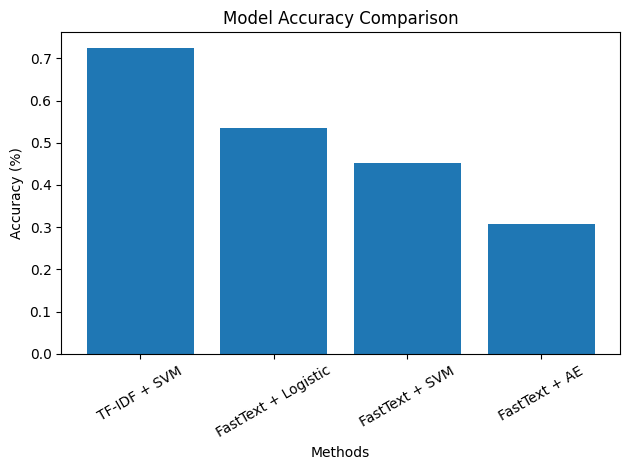

In [48]:
import matplotlib.pyplot as plt

methods = [
    "TF-IDF + SVM",
    "FastText + Logistic",
    "FastText + SVM",
    "FastText + AE"
]

accuracy = [tfidf_svm_acc,fasttext_logacc,fasttext_svm,fasttext_ae_acc]

plt.figure()
plt.bar(methods, accuracy)

plt.title("Model Accuracy Comparison")
plt.xlabel("Methods")
plt.ylabel("Accuracy (%)")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

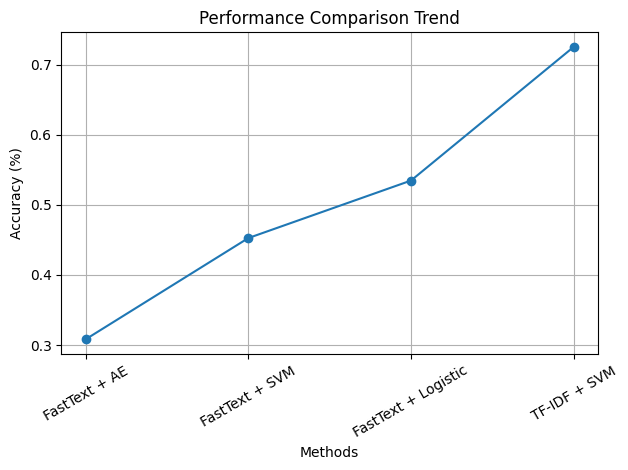

In [49]:
import matplotlib.pyplot as plt

methods = [
    "TF-IDF + SVM",
    "FastText + Logistic",
    "FastText + SVM",
    "FastText + AE"
]
methods=methods[::-1]
accuracy = [tfidf_svm_acc,fasttext_logacc,fasttext_svm,fasttext_ae_acc]
accuracy=accuracy[::-1]
plt.figure()
plt.plot(methods, accuracy, marker='o')

plt.title("Performance Comparison Trend")
plt.xlabel("Methods")
plt.ylabel("Accuracy (%)")

plt.xticks(rotation=30)
plt.grid()
plt.tight_layout()

plt.show()

## TF-IDF : With ngram and svm

In [50]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer1 = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 3)   # unigram + bigram
)

X_train_tfidf_n = vectorizer1.fit_transform(train['clean_text'])
X_test_tfidf_n = vectorizer1.transform(test['clean_text'])

In [51]:
from sklearn.svm import SVC

svm_tf = SVC(class_weight='balanced')

svm_tf.fit(X_train_tfidf_n, y_train)

y_pred_tfidf_n= svm_tf.predict(X_test_tfidf_n)

In [52]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_tfidf_n))

Accuracy: 0.7205542725173211
